In [62]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score , classification_report, RocCurveDisplay, ConfusionMatrixDisplay , confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [4]:
df = pd.read_csv('C:/Users/Mohamed/OneDrive/Desktop/Hotel/hotel_booking.csv')

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [6]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0


In [9]:
ccs = [
    'hotel',
    'is_canceled',
    'arrival_date_year',
    'arrival_date_month',
    'meal',
    'country',
    'market_segment',
    'distribution_channel',
    'is_repeated_guest',
    'reserved_room_type',
    'assigned_room_type',
    'deposit_type',
    'agent',
    'company',
    'customer_type',
    'reservation_status',
    'name',
    'email',
    'phone-number',
    'credit_card'
]
for column in ccs:
    if column in df.columns:
        df[column] = df[column].astype(str)
df.dtypes

hotel                                 str
is_canceled                           str
lead_time                           int64
arrival_date_year                     str
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
country                               str
market_segment                        str
distribution_channel                  str
is_repeated_guest                     str
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
assigned_room_type                    str
booking_changes                     int64
deposit_type                          str
agent                             

In [10]:
df.describe(include='object').T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
is_canceled,119390,2,0,75166
arrival_date_year,119390,3,2016,56707
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
is_repeated_guest,119390,2,0,115580
reserved_room_type,119390,10,A,85994


In [11]:
df = pd.read_csv('C:/Users/Mohamed/OneDrive/Desktop/Hotel/hotel_booking.csv')

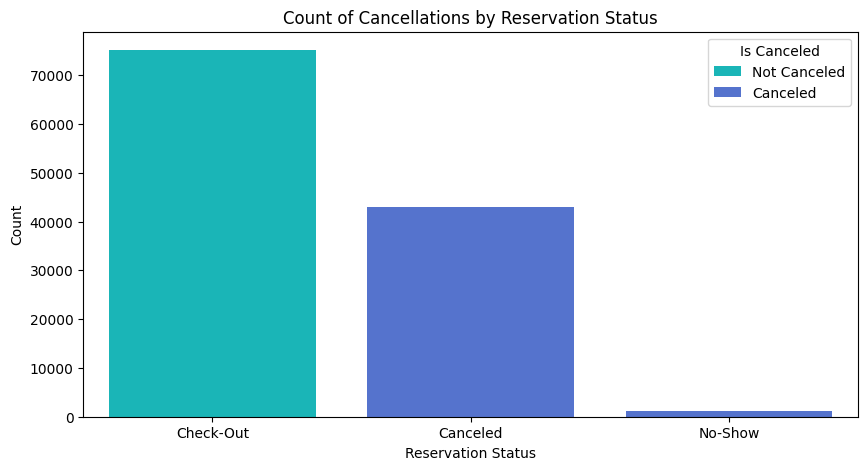

In [12]:
# Bivariate bar plot of 'is_canceled' vs 'reservation_status' with specified colors
plt.figure(figsize=(10, 5))
sns.countplot(x='reservation_status', hue='is_canceled', data=df, palette=['darkturquoise', 'royalblue'])
plt.title('Count of Cancellations by Reservation Status')
plt.xlabel('Reservation Status')
plt.ylabel('Count')
plt.legend(title='Is Canceled', labels=['Not Canceled', 'Canceled'])
plt.show()

In [13]:
df.groupby('reservation_status')['is_canceled'].mean()

reservation_status
Canceled     1.0
Check-Out    0.0
No-Show      1.0
Name: is_canceled, dtype: float64

In [18]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
df['reservation_status_days_difference'] = (df['reservation_status_date'] - pd.to_datetime(df['arrival_date_year'].astype(str) + '-' + df['arrival_date_month'] + '-' + df['arrival_date_day_of_month'].astype(str))).dt.days
df[['reservation_status_days_difference']].head()

,reservation_status_days_difference
0,0
1,0
2,1
3,1
4,2


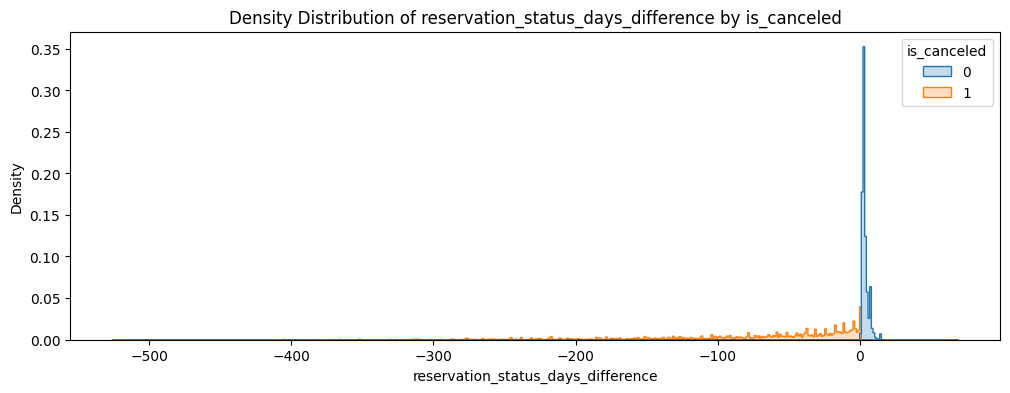

In [19]:
plt.figure(figsize=(12, 4))
sns.histplot(data=df, x="reservation_status_days_difference", hue="is_canceled", element="step", stat="density", common_norm=False)
plt.title('Density Distribution of reservation_status_days_difference by is_canceled')
plt.show()

In [21]:

print("'is_canceled' when 'reservation_status_days_difference' is positive:")
print(df[df['reservation_status_days_difference'] > 0]['is_canceled'].value_counts())
print('---------------------------------------------')
print("'is_canceled' when 'reservation_status_days_difference' is negative:")
print(df[df['reservation_status_days_difference'] < 0]['is_canceled'].value_counts())

'is_canceled' when 'reservation_status_days_difference' is positive:
is_canceled
0    74460
Name: count, dtype: int64
---------------------------------------------
'is_canceled' when 'reservation_status_days_difference' is negative:
is_canceled
1    42137
Name: count, dtype: int64


In [22]:
df = df.drop(['reservation_status_date', 'reservation_status_days_difference'], axis=1)

In [23]:
df = df.drop(['assigned_room_type'], axis=1)

In [24]:
df['arrival_date_year'].value_counts()

arrival_date_year
2016    56707
2017    40687
2015    21996
Name: count, dtype: int64

In [25]:
df = df.drop(['arrival_date_year'], axis=1)

In [26]:
high_cardinality_features = ['country', 'agent', 'company', 'name', 'email', 'phone-number', 'credit_card']
unique_categories = df[high_cardinality_features].nunique()
missing_values = df[high_cardinality_features].isnull().sum()
high_cardinality_df = pd.DataFrame({'Unique_Categories': unique_categories, 'Missing_Values': missing_values})
high_cardinality_df

,Unique_Categories,Missing_Values
country,177,488
agent,333,16340
company,352,112593
name,81503,0
email,115889,0
phone-number,119390,0
credit_card,9000,0


In [27]:
df['number_of_bookings'] = df.groupby('name')['name'].transform('count')
df = df.drop(['name', 'country', 'agent', 'company', 'email', 'phone-number', 'credit_card'], axis=1)
df[['number_of_bookings']].head()

,number_of_bookings
0,1
1,2
2,3
3,1
4,1


In [28]:
df['children'].value_counts()

children
0.0     110796
1.0       4861
2.0       3652
3.0         76
10.0         1
Name: count, dtype: int64

In [29]:
df['children'] = df['children'].fillna(0)
df['children'].isnull().sum()

np.int64(0)

In [30]:
noisy_data = {
    'adr':      df[df['adr'] < 0],
    'adults':   df[df['adults'] == 0],
    'children': df[df['children'] == 10],
    'babies':   df[df['babies'] == 10],
}
noisy_data_count = {key: len(value) for key, value in noisy_data.items()}
noisy_data_count

{'adr': 1, 'adults': 403, 'children': 1, 'babies': 1}

In [31]:
df.loc[df['adr'] < 0, 'adr'] = df['adr'].median()

# Remove rows with 0 adults
df = df[df['adults'] != 0]
df = df[df['children'] != 10]
df = df[df['babies'] != 10]
df.reset_index(drop=True, inplace=True)
noisy_data_handled = {
    'adr': df[df['adr'] < 0],
    'adults': df[df['adults'] == 0],
    'children': df[df['children'] == 10],
    'babies': df[df['babies'] == 10],
}
noisy_data_handled_count = {key: len(value) for key, value in noisy_data_handled.items()}
noisy_data_handled_count

{'adr': 0, 'adults': 0, 'children': 0, 'babies': 0}

In [32]:
df.dtypes

hotel                                 str
is_canceled                         int64
lead_time                           int64
arrival_date_month                    str
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                                  str
market_segment                        str
distribution_channel                  str
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                    str
booking_changes                     int64
deposit_type                          str
days_in_waiting_list                int64
customer_type                         str
adr                               float64
required_car_parking_spaces       

In [33]:
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
df['arrival_date_month'] = df['arrival_date_month'].apply(lambda x: months.index(x) + 1)
one_hot_cols = ['hotel', 'meal', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type']
df = pd.get_dummies(df, columns=one_hot_cols, drop_first=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118985 entries, 0 to 118984
Data columns (total 48 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   is_canceled                     118985 non-null  int64  
 1   lead_time                       118985 non-null  int64  
 2   arrival_date_month              118985 non-null  int64  
 3   arrival_date_week_number        118985 non-null  int64  
 4   arrival_date_day_of_month       118985 non-null  int64  
 5   stays_in_weekend_nights         118985 non-null  int64  
 6   stays_in_week_nights            118985 non-null  int64  
 7   adults                          118985 non-null  int64  
 8   children                        118985 non-null  float64
 9   babies                          118985 non-null  int64  
 10  is_repeated_guest               118985 non-null  int64  
 11  previous_cancellations          118985 non-null  int64  
 12  previous_bookings_not_cance

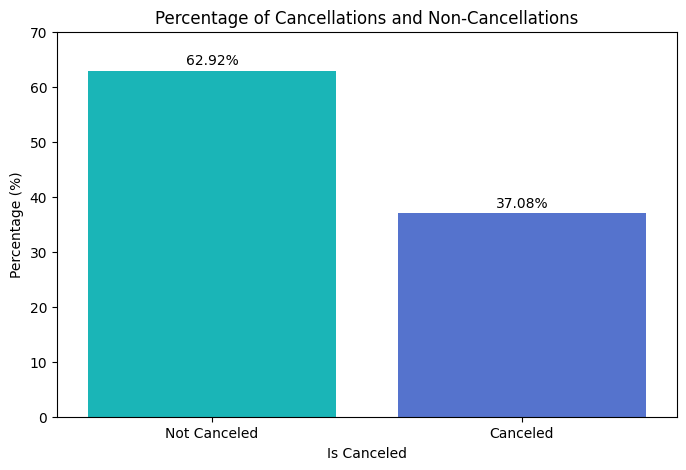

In [34]:
percentage = df['is_canceled'].value_counts(normalize=True) * 100
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=percentage.index, y=percentage, palette=['darkturquoise', 'royalblue'])
plt.title('Percentage of Cancellations and Non-Cancellations')
plt.xlabel('Is Canceled')
plt.ylabel('Percentage (%)')
plt.xticks(ticks=[0, 1], labels=['Not Canceled', 'Canceled'])
plt.yticks(ticks=range(0,80,10))
for i, p in enumerate(percentage):
    ax.text(i, p + 0.5, f'{p:.2f}%', ha='center', va='bottom')

plt.show()

In [35]:
x = df.drop('is_canceled', axis=1)
y = df['is_canceled'] 

In [36]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Test Model 
1 - Random Forest
2 - Xgboost 
3 - MLP

In [42]:
rf = RandomForestClassifier(random_state=42,n_estimators=150,criterion='entropy',max_depth=16,min_samples_split=4,class_weight={0: 1, 1: 2})

In [43]:
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",16
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metri

In [44]:
rf.score(x_test, y_test)

0.8252720931209816

In [46]:
print(classification_report(y_test, rf.predict(x_test)))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86     14974
           1       0.75      0.80      0.77      8823

    accuracy                           0.83     23797
   macro avg       0.81      0.82      0.82     23797
weighted avg       0.83      0.83      0.83     23797



In [56]:
auc_score_rf = roc_auc_score(y_test, rf.predict_proba(x_test)[:, 1])

In [57]:
auc_score_rf

0.9069508648948214

-----------------------------------------------------------

In [51]:
xgbm = xgb.XGBClassifier(random_state=42, n_estimators=250, max_depth=8, learning_rate=0.1, scale_pos_weight=2,subsample=0.8, colsample_bytree=0.8)

In [52]:
xgbm.fit(x_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [54]:
print(classification_report(y_test, xgbm.predict(x_test)))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87     14974
           1       0.76      0.82      0.79      8823

    accuracy                           0.84     23797
   macro avg       0.82      0.83      0.83     23797
weighted avg       0.84      0.84      0.84     23797



In [58]:
auc_score_XGB = roc_auc_score(y_test, xgbm.predict_proba(x_test)[:, 1])

In [59]:
auc_score_XGB

0.9184634340159159

-----------------------------------------------------------

In [60]:
input_shape = x_train.shape[1]
model = Sequential([
    
    Dense(128, activation='relu', input_shape=(input_shape,)),
    BatchNormalization(),
    Dropout(0.3),         
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
 
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10,        
    restore_best_weights=True 
)

history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=100,      
    batch_size=64,        
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.7104 - auc: 0.7451 - loss: 0.5642 - val_accuracy: 0.7954 - val_auc: 0.8519 - val_loss: 0.4437
Epoch 2/100
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7931 - auc: 0.8368 - loss: 0.4529 - val_accuracy: 0.7722 - val_auc: 0.8611 - val_loss: 0.4546
Epoch 3/100
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7990 - auc: 0.8459 - loss: 0.4398 - val_accuracy: 0.8130 - val_auc: 0.8667 - val_loss: 0.4151
Epoch 4/100
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8024 - auc: 0.8508 - loss: 0.4320 - val_accuracy: 0.8071 - val_auc: 0.8634 - val_loss: 0.4163
Epoch 5/100
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8031 - auc: 0.8544 - loss: 0.4279 - val_accuracy: 0.8127 - val_auc: 0.8721 - val_loss: 0.4102
Epoch 6/100
1488/1488 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8040 - auc: 0.8551 - loss: 0.4267 - val_accuracy: 0.7767 - val_auc: 0.8650 - val_loss: 0.4370
Epoch 7/100
1488/1488

In [61]:
y_pred_proba_dl = model.predict(x_test).ravel()
y_pred_labels_dl = (y_pred_proba_dl > 0.5).astype(int)
print("Classification Report:")
print(classification_report(y_test, y_pred_labels_dl))

744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87     14974
           1       0.84      0.64      0.73      8823

    accuracy                           0.82     23797
   macro avg       0.83      0.78      0.80     23797
weighted avg       0.82      0.82      0.82     23797



744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Deep Learning ROC AUC Score: 0.8879


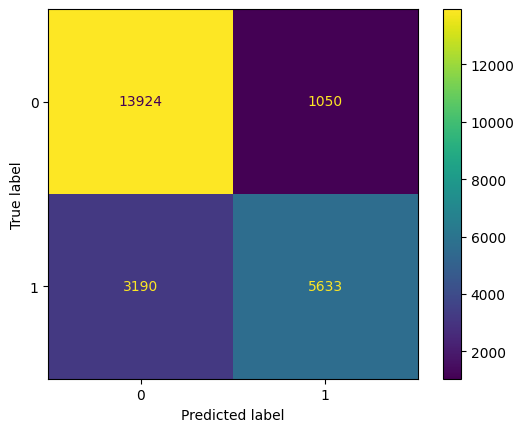

In [63]:
y_pred_proba_dl = model.predict(x_test).ravel()
dl_auc = roc_auc_score(y_test, y_pred_proba_dl)
print(f"Deep Learning ROC AUC Score: {dl_auc:.4f}")
y_pred_labels_dl = (y_pred_proba_dl > 0.5).astype(int)
cm_dl = confusion_matrix(y_test, y_pred_labels_dl)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dl)
disp.plot()

In [70]:


# - Random Forest
y_pred_rf = rf.predict(x_test)
y_proba_rf = rf.predict_proba(x_test)[:, 1]
# - XGBoost
y_pred_xgb = xgbm.predict(x_test)
y_proba_xgb = xgbm.predict_proba(x_test)[:, 1]
# - MLP
y_proba_dl = model.predict(x_test).ravel()
y_pred_dl = (y_proba_dl > 0.5).astype(int)


results = {
    'Model': ['Random Forest', 'XGBoost', 'Deep Learning'],
    
    'ROC AUC Score': [
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_dl)
    ],
    
    'Precision (Class 1)': [
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_dl)
    ],
    
    'Recall (Class 1)': [
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_dl)
    ],
    
    'F1-Score (Class 1)': [
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_dl)
    ]
}
df_compare = pd.DataFrame(results)
df_compare = df_compare.sort_values(by='ROC AUC Score', ascending=False).reset_index(drop=True)
print("Models Performance Comparison : ")
display(df_compare)

744/744 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Models Performance Comparison : 


,Model,ROC AUC Score,Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
0,XGBoost,0.918463,0.759298,0.823756,0.790215
1,Random Forest,0.906951,0.745449,0.802902,0.773109
2,Deep Learning,0.887920,0.842885,0.638445,0.726557


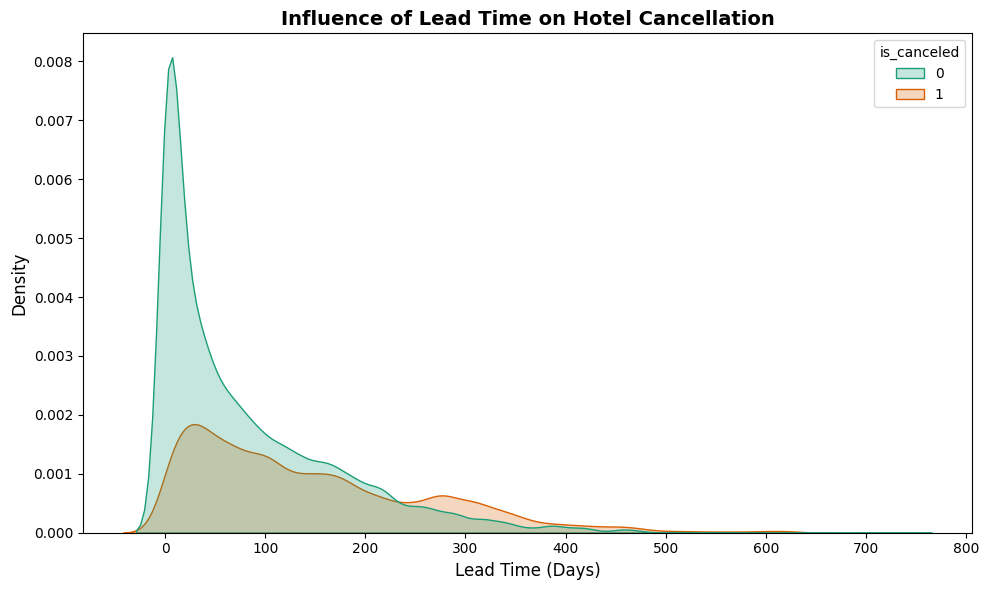

In [69]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
# الرسمة دي هتقسم الـ Lead time وتشوف نسبة الإلغاء (Is Canceled)
sns.kdeplot(data=df, x='lead_time', hue='is_canceled', shade=True, palette='Dark2')

plt.title('Influence of Lead Time on Hotel Cancellation', fontsize=14, fontweight='bold')
plt.xlabel('Lead Time (Days)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.show()